In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Loading MNIST Dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


# Visualize Original Images

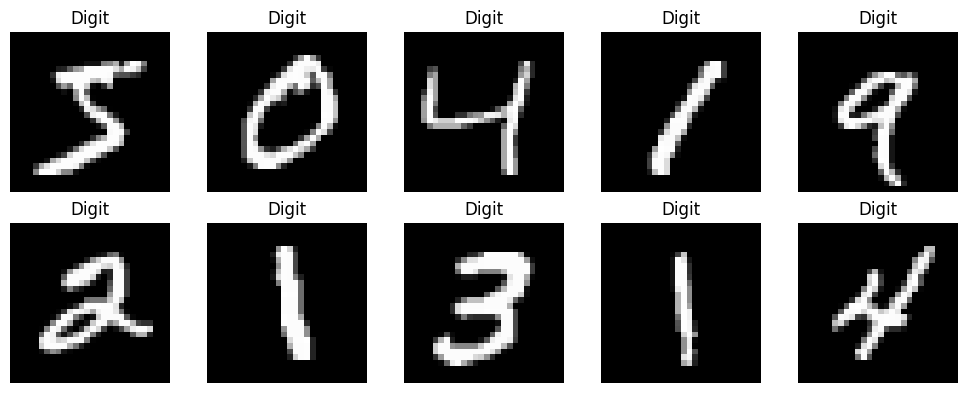

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.title("Digit")

plt.tight_layout()
plt.show()

# Normalizing

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [6]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


# Adding Noise

In [7]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [8]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Clean and Noisy Image

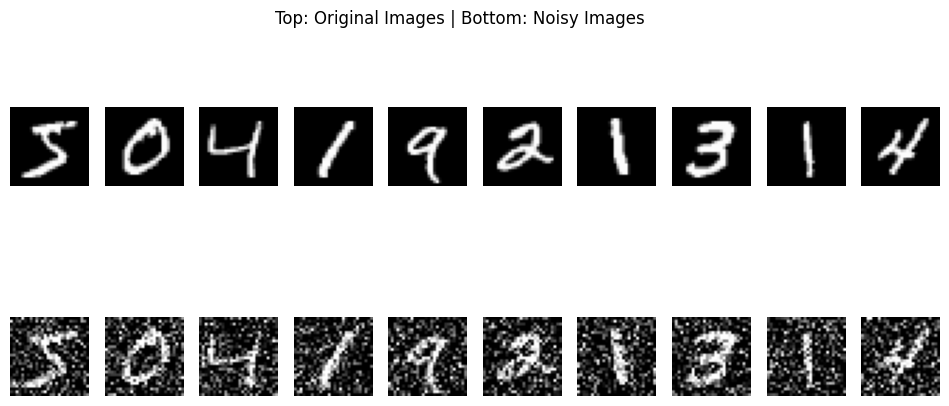

In [10]:
plt.figure(figsize=(12, 5))

for i in range(10):


    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')


    plt.subplot(2, 10, i + 11)
    plt.imshow(x_train_noisy[i], cmap='gray')
    plt.axis('off')

plt.suptitle("Top: Original Images | Bottom: Noisy Images")
plt.show()

In [11]:
input_img = Input(shape=(28, 28))
x = Flatten()(input_img)

# Encoder
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

# Latent representation
encoded = Dense(32, activation='relu')(x)

# Decoder
x = Dense(64, activation='relu')(encoded)
x = Dense(128, activation='relu')(x)

x = Dense(784, activation='sigmoid')(x)

# Reshape back to 28x28
decoded = Reshape((28, 28))(x)

# Create Autoencoder
autoencoder = Model(input_img, decoded)

In [12]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

In [13]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2650 - val_loss: 0.1975
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1764 - val_loss: 0.1607
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1545 - val_loss: 0.1483
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1456 - val_loss: 0.1417
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1403 - val_loss: 0.1368
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1361 - val_loss: 0.1332
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1326 - val_loss: 0.1300
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1297 - val_loss: 0.1272
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1271 - val_loss: 0.1249
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1247 - val_loss: 0.1226
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.1227 - val_loss: 0.1217
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

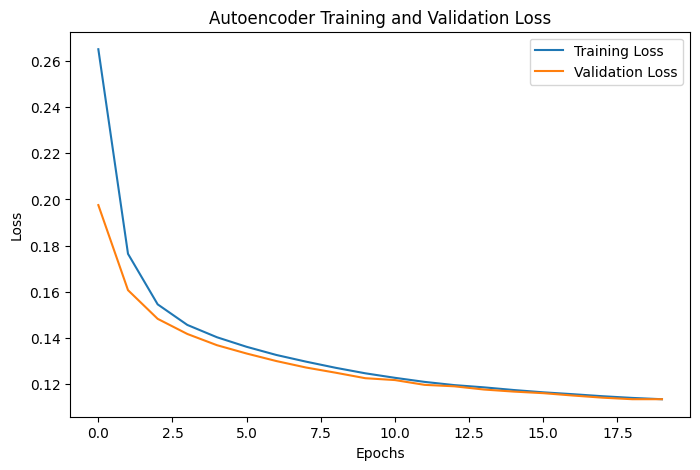

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


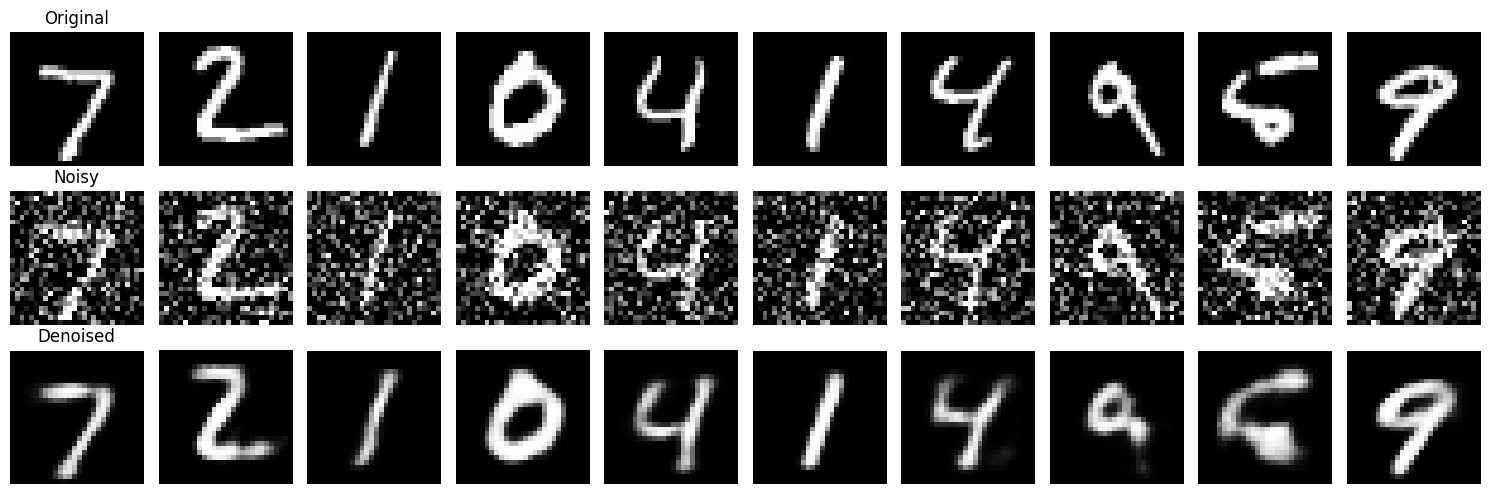

In [19]:
n = 10

plt.figure(figsize=(15, 5))

for i in range(n):

    # Original clean image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Original")

    # Noisy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Noisy")

    # Denoised image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title("Denoised")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    x_test.reshape(-1),
    denoised_images.reshape(-1)
)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.01468333974480629


# Obsevation
The autoencoder successfully learned to remove Gaussian noise from MNIST handwritten digit images. The training and validation loss decreased consistently during training, indicating that the model learned to reconstruct clean images from noisy inputs. The denoised images were visually clearer than the noisy images and preserved the important shapes and structures of the handwritten digits. The model achieved a Mean Squared Error (MSE) of approximately 0.01468, indicating good reconstruction quality.

# Conclusion
The denoising autoencoder successfully reconstructed clean MNIST images from noisy inputs. The results demonstrate that autoencoders can learn meaningful image representations and effectively reduce noise without requiring labeled class information. The low MSE and visual quality of the reconstructed images confirm that the model performed well for the image denoising task.